# CIFAR-100 — Transfer Learning with EfficientNet-B0

Fine-tuning a pre-trained EfficientNet-B0 (ImageNet weights) on CIFAR-100.

**Strategy:**
- Resize CIFAR-100 images 32×32 → 224×224 (EfficientNet-B0 native resolution)
- Load `efficientnet_b0(weights='DEFAULT')` with ImageNet pre-trained weights
- Replace the final classifier head for 100 classes
- Two-phase training:
  - **Phase 1** — Freeze backbone, train head only (fast warm-up, 10 epochs)
  - **Phase 2** — Unfreeze all layers, fine-tune end-to-end with a lower LR (50 epochs)
- AMP (mixed precision) + `ModelCheckpoint` for safety


## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim
from torch.amp import GradScaler

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch


## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')


Using device: cuda


## Data Pipeline

EfficientNet-B0 was trained on 224×224 ImageNet images, so we resize CIFAR-100
to match. ImageNet normalization stats are used since the backbone expects them.


In [3]:
batch_size = 64

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
    use_imagenet_stats=True,
)
print(f'Train: {len(trainloader)} | Val: {len(valloader)} | Test: {len(testloader)}')


C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 625 | Val: 157 | Test: 157


## Visualize Sample Batch

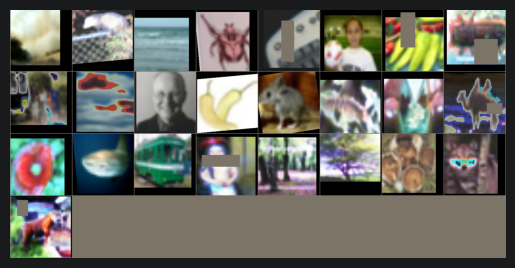

cloud possum sea   beetle keyboard girl  sweet_pepper beetle bus   cloud man   sweet_pepper mouse caterpillar sweet_pepper camel poppy seal  streetcar boy   forest maple_tree mushroom wolf  tiger


In [4]:
show_sample_batch(trainloader, CIFAR100_CLASSES, n=25)

## Model: Pre-trained EfficientNet-B0

We load the official EfficientNet-B0 backbone (torchvision, ImageNet weights) and
replace only its final classifier layer.

**EfficientNet-B0 head structure (original):**
```
classifier[0]: Dropout(p=0.2)
classifier[1]: Linear(1280, 1000)
```
We keep the dropout and swap the linear for 100 classes.


In [5]:
model = models.efficientnet_b0(weights='DEFAULT')

# Replace the classifier head — keep the built-in Dropout(0.2)
in_features = model.classifier[1].in_features   # 1280
model.classifier[1] = nn.Linear(in_features, 100)

model = model.to(device)
total_params  = sum(p.numel() for p in model.parameters())
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'Total parameters:    {total_params:,}')
print(f'Trainable parameters:{total_params - frozen_params:,}')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\asmit/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Total parameters:    4,135,648
Trainable parameters:4,135,648


## Phase 1 — Head-Only Training (Frozen Backbone)

Freeze all backbone layers and train only the new classifier head.
This is a quick warm-up (10 epochs) that teaches the head to map
EfficientNet features to CIFAR-100 classes before we disturb the backbone weights.


In [6]:
# Freeze everything except the classifier
for param in model.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 trainable params: {trainable:,}  (head only)')

PHASE1_EPOCHS = 10
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = GradScaler('cuda')

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=1e-5
)

NAME = 'efficientnet_b0_transfer_100'
checkpoint_p1 = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_phase1_last.pth',
    best_model_path=f'../../checkpoint/{NAME}_phase1_best.pth',
    mode='max',
    verbose=True,
)

train_losses_p1, val_losses_p1, val_accs_p1 = fit(
    model, trainloader, valloader, criterion,
    optimizer_p1, scheduler_p1, scaler, device,
    PHASE1_EPOCHS, checkpoint_p1,
    step_scheduler_per_batch=False,
)


Phase 1 trainable params: 128,100  (head only)
[ModelCheckpoint] New best (max): 53.9600 — saved to ..\checkpoint\efficientnet_b0_transfer_100_phase1_best.pth
Epoch [ 1/10]  Train Loss: 3.2697  Val Loss: 2.3855  Val Acc: 53.96%  LR: 0.000976  Time: 38.99s
[ModelCheckpoint] New best (max): 58.3100 — saved to ..\checkpoint\efficientnet_b0_transfer_100_phase1_best.pth
Epoch [ 2/10]  Train Loss: 2.7395  Val Loss: 2.2072  Val Acc: 58.31%  LR: 0.000905  Time: 19.49s
[ModelCheckpoint] New best (max): 59.8300 — saved to ..\checkpoint\efficientnet_b0_transfer_100_phase1_best.pth
Epoch [ 3/10]  Train Loss: 2.6457  Val Loss: 2.1398  Val Acc: 59.83%  LR: 0.000796  Time: 19.13s
[ModelCheckpoint] New best (max): 60.7600 — saved to ..\checkpoint\efficientnet_b0_transfer_100_phase1_best.pth
Epoch [ 4/10]  Train Loss: 2.6087  Val Loss: 2.1096  Val Acc: 60.76%  LR: 0.000658  Time: 19.04s
[ModelCheckpoint] New best (max): 61.6900 — saved to ..\checkpoint\efficientnet_b0_transfer_100_phase1_best.pth
Epoch

### Phase 1 Training Curves

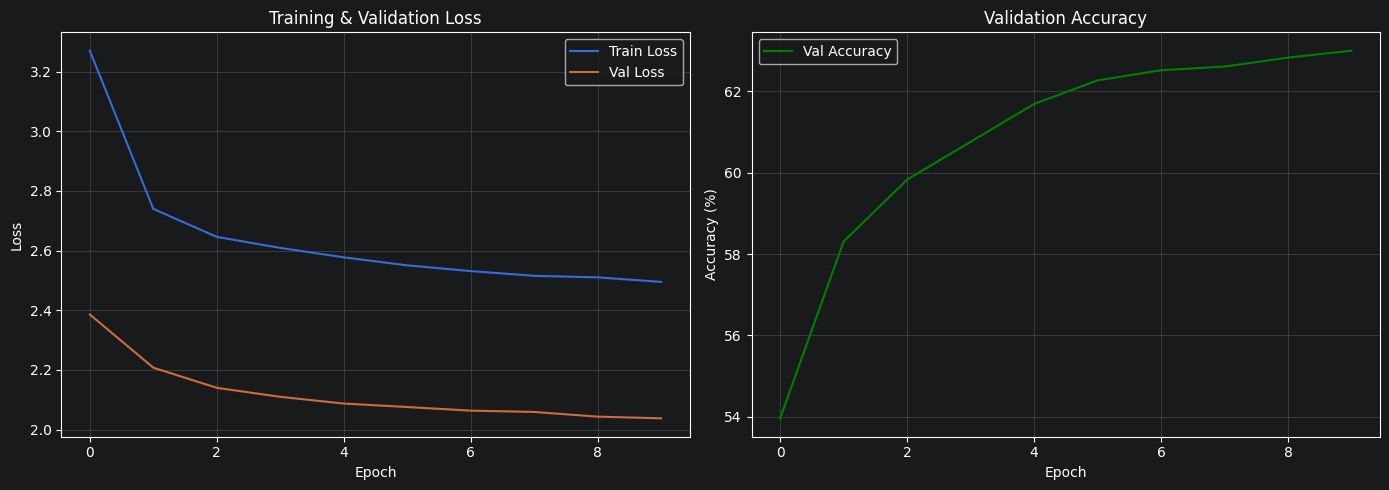

In [7]:
plot_training_curves(train_losses_p1, val_losses_p1, val_accs_p1)

## Phase 2 — Full Fine-Tuning (Unfrozen Backbone)

Unfreeze all layers and fine-tune end-to-end with a much lower learning rate.
Using differential learning rates:
- **Backbone** gets a lower LR (`1e-4`) — don't destroy pre-trained features
- **Head** gets a higher LR (`5e-4`) — still learning fast

OneCycleLR gives a smooth warm-up + cosine decay, which works very well for fine-tuning.


In [8]:
# Unfreeze all backbone layers
for param in model.features.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable params: {trainable:,}  (full model)')

PHASE2_EPOCHS = 50

# Differential learning rates: lower LR for backbone, higher for head
optimizer_p2 = optim.SGD(
    [
        {'params': model.features.parameters(), 'lr': 1e-4},
        {'params': model.classifier.parameters(), 'lr': 5e-4},
    ],
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True,
)

scheduler_p2 = optim.lr_scheduler.OneCycleLR(
    optimizer_p2,
    max_lr=[1e-3, 5e-3],          # peak LRs (10x the base LRs)
    steps_per_epoch=len(trainloader),
    epochs=PHASE2_EPOCHS,
    pct_start=0.1,                # 10% warm-up
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e3,
)

checkpoint_p2 = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_last.pth',
    best_model_path=f'../../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=True,
)

train_losses_p2, val_losses_p2, val_accs_p2 = fit(
    model, trainloader, valloader, criterion,
    optimizer_p2, scheduler_p2, scaler, device,
    PHASE2_EPOCHS, checkpoint_p2,
    step_scheduler_per_batch=True,   # OneCycleLR steps per batch
)


Phase 2 trainable params: 4,135,648  (full model)


C:\Users\asmit\PycharmProjects\CIFAR_10\utils\training.py:114: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[ModelCheckpoint] New best (max): 69.3500 — saved to ..\checkpoint\efficientnet_b0_transfer_100_best.pth
Epoch [ 1/50]  Train Loss: 2.2171  Val Loss: 1.8086  Val Acc: 69.35%  LR: 0.000186  Time: 46.21s
[ModelCheckpoint] New best (max): 73.1900 — saved to ..\checkpoint\efficientnet_b0_transfer_100_best.pth
Epoch [ 2/50]  Train Loss: 1.9562  Val Loss: 1.6910  Val Acc: 73.19%  LR: 0.000411  Time: 38.61s
[ModelCheckpoint] New best (max): 75.3300 — saved to ..\checkpoint\efficientnet_b0_transfer_100_best.pth
Epoch [ 3/50]  Train Loss: 1.8249  Val Loss: 1.6111  Val Acc: 75.33%  LR: 0.000689  Time: 38.41s
[ModelCheckpoint] New best (max): 76.9400 — saved to ..\checkpoint\efficientnet_b0_transfer_100_best.pth
Epoch [ 4/50]  Train Loss: 1.7303  Val Loss: 1.5618  Val Acc: 76.94%  LR: 0.000914  Time: 38.49s
[ModelCheckpoint] New best (max): 78.3500 — saved to ..\checkpoint\efficientnet_b0_transfer_100_best.pth
Epoch [ 5/50]  Train Loss: 1.6725  Val Loss: 1.5132  Val Acc: 78.35%  LR: 0.001000  Tim

### Phase 2 Training Curves

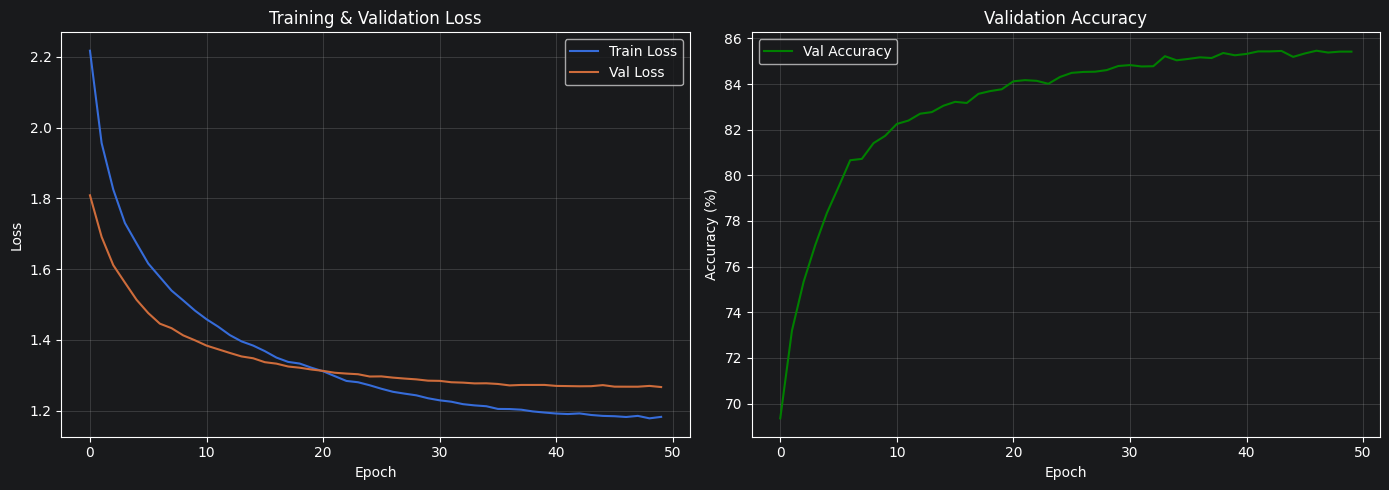

In [9]:
plot_training_curves(train_losses_p2, val_losses_p2, val_accs_p2)

## Restore Best Weights & Test Evaluation

In [10]:
checkpoint_p2.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'Test Accuracy: {overall_acc:.2f}%\n')

print('Per-class accuracies (best first):')
sorted_classes = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
for cls, acc in sorted_classes:
    bar = '\u2588' * int(acc / 5)
    print(f'  {cls:<20s} {acc:5.1f}%  {bar}')


[ModelCheckpoint] Restored best weights from ..\checkpoint\efficientnet_b0_transfer_100_best.pth (score=85.4600)
Test Accuracy: 85.75%

Per-class accuracies (best first):
  apple                 97.0%  ███████████████████
  chimpanzee            97.0%  ███████████████████
  motorcycle            97.0%  ███████████████████
  pickup_truck          97.0%  ███████████████████
  road                  97.0%  ███████████████████
  skunk                 97.0%  ███████████████████
  tank                  97.0%  ███████████████████
  lawn_mower            96.0%  ███████████████████
  orange                96.0%  ███████████████████
  tractor               96.0%  ███████████████████
  wardrobe              96.0%  ███████████████████
  spider                95.0%  ███████████████████
  sunflower             95.0%  ███████████████████
  television            95.0%  ███████████████████
  bottle                94.0%  ██████████████████
  chair                 94.0%  ██████████████████
  lion         